In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("googleplaystore.csv")

# Display the first 5 rows
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [3]:
df['Installs'].value_counts().head(10)

Installs
1,000,000+     1579
10,000,000+    1252
100,000+       1169
10,000+        1054
1,000+          907
5,000,000+      752
100+            719
500,000+        539
50,000+         479
5,000+          477
Name: count, dtype: int64

In [4]:
df[~df['Installs'].str.endswith('+')]['Installs'].value_counts()

Installs
0       1
Free    1
Name: count, dtype: int64

In [5]:
df[df['Installs'] == 'Free']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [6]:
df = df.drop(10472)

In [7]:
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = df['Installs'].astype(int)

In [8]:
df['Installs'].dtype

dtype('int64')

In [9]:
df['Price'].value_counts().head(10)

Price
0        10040
$0.99      148
$2.99      129
$1.99       73
$4.99       72
$3.99       63
$1.49       46
$5.99       30
$2.49       26
$9.99       21
Name: count, dtype: int64

In [10]:
df[~df['Price'].str.startswith('$')]['Price'].value_counts()

Price
0    10040
Name: count, dtype: int64

In [11]:
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = df['Price'].astype(float)

In [12]:
df['Reviews'] = df['Reviews'].astype(int)

In [13]:
df['Size'].value_counts().head(10)

Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
15M                    184
17M                    160
19M                    154
26M                    149
16M                    149
Name: count, dtype: int64

In [14]:
def clean_size(val):
    if 'M' in val:
        return float(val.replace('M', ''))
    elif 'k' in val:
        return float(val.replace('k', '')) / 1024
    else:
        return np.nan

In [15]:
df['Size'] = df['Size'].apply(clean_size)

In [16]:
df['Size'].dtype

dtype('float64')

In [17]:
df['Size'].head()

0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64

In [18]:
df['App'].duplicated().sum()

np.int64(1181)

In [19]:
df = df.drop_duplicates(subset=['App'])

In [20]:
df.shape

(9659, 13)

In [21]:
df.isna().sum()

App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [22]:
df['Rating'].mean()

np.float64(4.173243045387994)

In [23]:
# 1. Impute missing ratings with the average rating
mean_rating = round(df['Rating'].mean(), 1)
df['Rating'] = df['Rating'].fillna(mean_rating)

# 2. Drop the small handful of remaining null rows
df = df.dropna(subset=['Type', 'Current Ver', 'Android Ver'])

In [24]:
df.isna().sum()

App                  0
Category             0
Rating               0
Reviews              0
Size              1226
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
dtype: int64

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean grid theme for our charts
sns.set_theme(style="whitegrid")

In [26]:
top_categories = df['Category'].value_counts().head(10)
top_categories

Category
FAMILY             1828
GAME                959
TOOLS               825
BUSINESS            420
MEDICAL             395
PERSONALIZATION     374
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64

C:\Users\lenovo\AppData\Local\Temp\ipykernel_13332\4208868730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


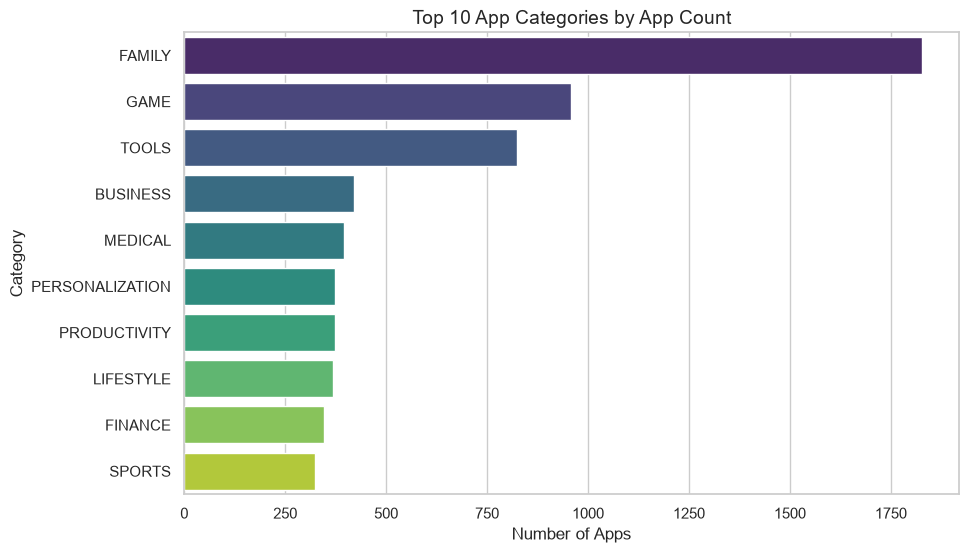

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')

plt.title('Top 10 App Categories by App Count', fontsize=14)
plt.xlabel('Number of Apps', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.show()

In [28]:
category_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)
category_installs

Category
GAME                  13878924415
COMMUNICATION         11038276251
TOOLS                  8001271905
PRODUCTIVITY           5793091369
SOCIAL                 5487867902
PHOTOGRAPHY            4649147655
FAMILY                 4427881405
VIDEO_PLAYERS          3926902720
TRAVEL_AND_LOCAL       2894887146
NEWS_AND_MAGAZINES     2369217760
Name: Installs, dtype: int64

C:\Users\lenovo\AppData\Local\Temp\ipykernel_13332\2166558266.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_13332\2166558266.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


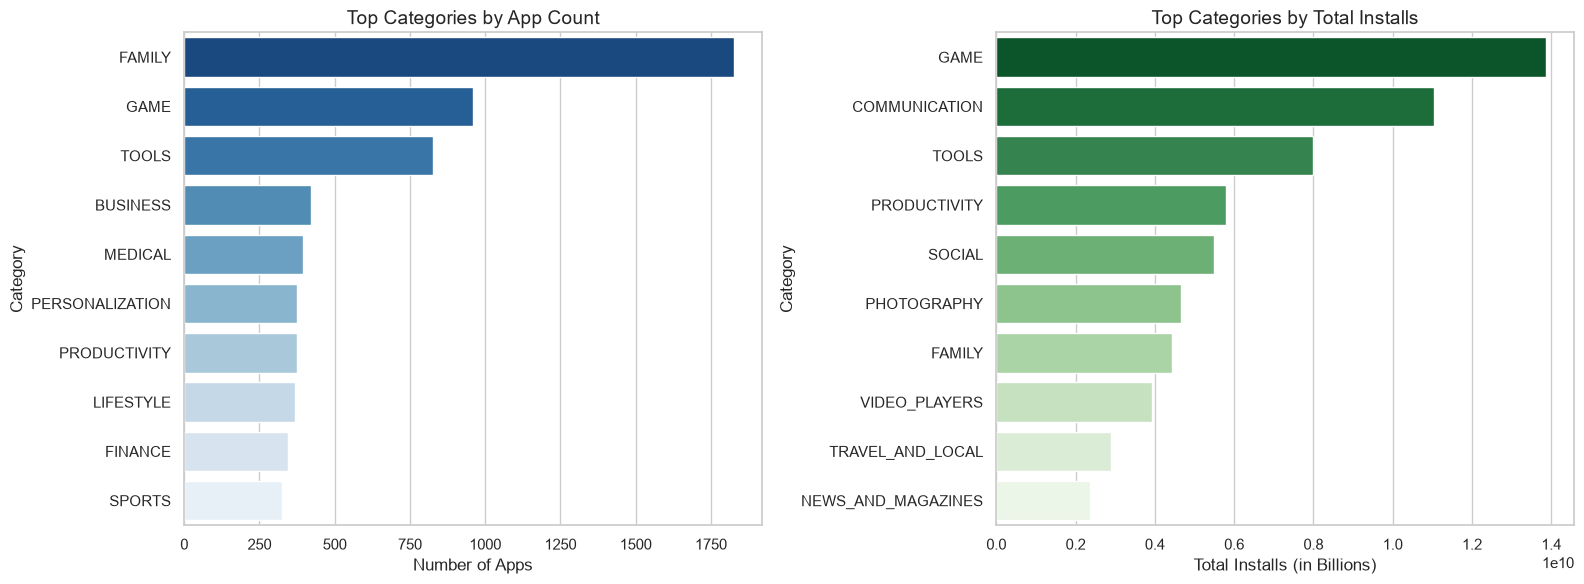

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: App Count
sns.barplot(
    ax=axes[0],
    x=top_categories.values,
    y=top_categories.index,
    palette='Blues_r'
)
axes[0].set_title('Top Categories by App Count', fontsize=14)
axes[0].set_xlabel('Number of Apps', fontsize=12)

# Plot 2: Total Installs
sns.barplot(
    ax=axes[1],
    x=category_installs.values,
    y=category_installs.index,
    palette='Greens_r'
)
axes[1].set_title('Top Categories by Total Installs', fontsize=14)
axes[1].set_xlabel('Total Installs (in Billions)', fontsize=12)

plt.tight_layout()
plt.show()

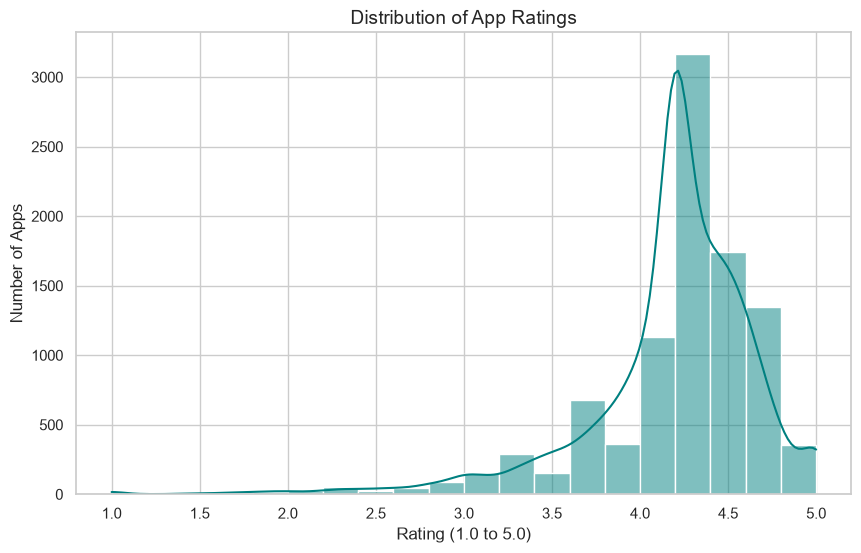

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=20, kde=True, color='teal')

plt.title('Distribution of App Ratings', fontsize=14)
plt.xlabel('Rating (1.0 to 5.0)', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.show()

In [31]:
df['Type'].value_counts()

Type
Free    8895
Paid     753
Name: count, dtype: int64

In [32]:
avg_rating = df.groupby('Type')['Rating'].mean()
avg_rating

Type
Free    4.171388
Paid    4.247809
Name: Rating, dtype: float64

C:\Users\lenovo\AppData\Local\Temp\ipykernel_13332\1326843630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Rating', data=df, palette='Set2')


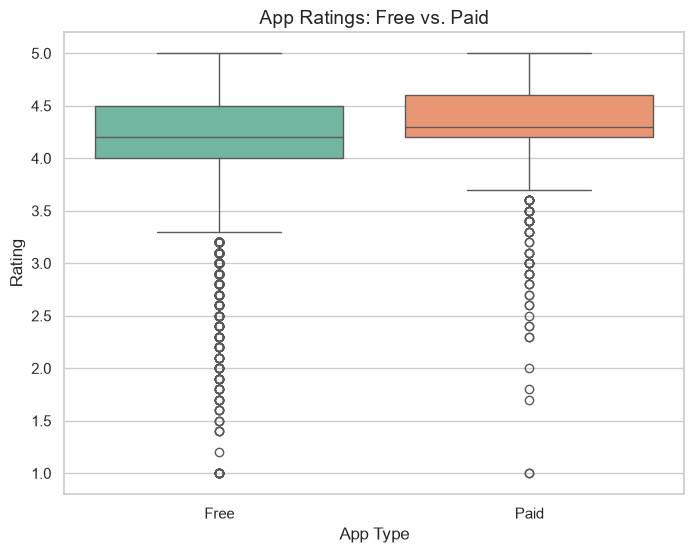

In [33]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Type', y='Rating', data=df, palette='Set2')

plt.title('App Ratings: Free vs. Paid', fontsize=14)
plt.xlabel('App Type', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

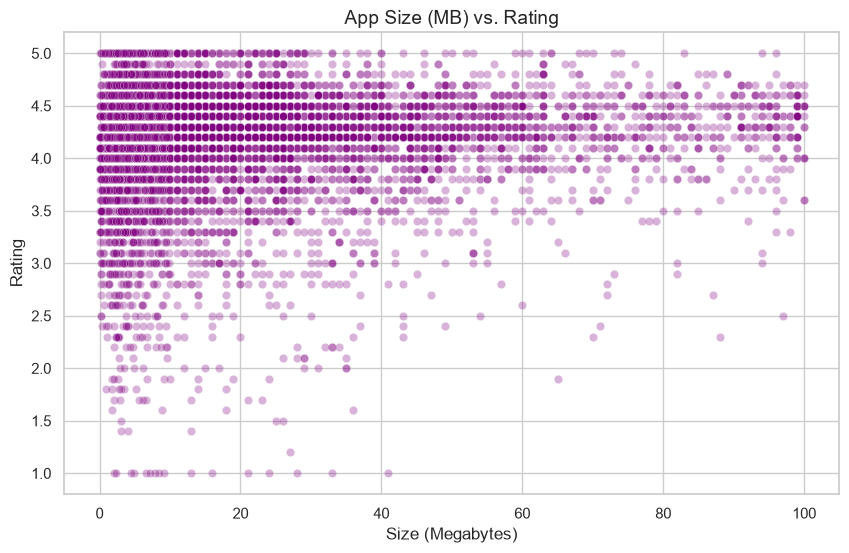

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size', y='Rating', data=df, alpha=0.3, color='purple')

plt.title('App Size (MB) vs. Rating', fontsize=14)
plt.xlabel('Size (Megabytes)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

In [35]:
df['Size'].corr(df['Rating'])

np.float64(0.055862782803359365)